In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import invwishart
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA

# ======================================================
# 1. Cargar datos
# ======================================================
url = "https://raw.githubusercontent.com/Andres1984/Data-Analysis-with-R/refs/heads/master/Bases/Smart_City_index.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

vars_cluster = [
    "Smart_Mobility",
    "Smart_Environment",
    "Smart_Government",
    "Smart_Economy",
    "Smart_People",
    "Smart_Living"
]

data = df[["City", "Country"] + vars_cluster].dropna().reset_index(drop=True)
X = data[vars_cluster].values
n, p = X.shape

print("Número de ciudades:", n)
print("Número de variables:", p)
print(data.head())


Número de ciudades: 102
Número de variables: 6
         City      Country  Smart_Mobility  Smart_Environment  \
0        Oslo       Norway            6480               6512   
1      Bergen       Norway            7097               6876   
2   Amsterdam  Netherlands            7540               5558   
3  Copenhagen      Denmark            7490               7920   
4   Stockholm       Sweden            6122               7692   

   Smart_Government  Smart_Economy  Smart_People  Smart_Living  
0              7516           4565          8618          9090  
1              7350           4905          8050          9090  
2              8528           8095          7098          7280  
3              8726           5580          5780          7200  
4              8354           4330          6743          7730  


In [2]:

# ======================================================
# 2. Hiperparámetros previos NIW
# ======================================================
mu0 = X.mean(axis=0) - 5.0
kappa0 = 0.5
nu0 = p + 5
sample_vars = X.var(axis=0, ddof=1)
S0 = np.diag(sample_vars * 1.5)

# ======================================================
# 3. Estadísticos muestrales
# ======================================================
xbar = X.mean(axis=0)
X_centered = X - xbar
Sn = X_centered.T @ X_centered

# ======================================================
# 4. Actualización posterior NIW
# ======================================================
kappa_n = kappa0 + n
nu_n = nu0 + n
mu_n = (kappa0 * mu0 + n * xbar) / kappa_n

diff = (xbar - mu0).reshape(-1, 1)
S_n = S0 + Sn + (kappa0 * n / kappa_n) * (diff @ diff.T)

print("\nMedia posterior global (mu_n):")
print(pd.Series(mu_n, index=vars_cluster).round(3))




Media posterior global (mu_n):
Smart_Mobility       5759.378
Smart_Environment    5943.476
Smart_Government     5893.780
Smart_Economy        6131.780
Smart_People         5874.025
Smart_Living         6377.015
dtype: float64


In [3]:
# ======================================================
# 5. Simulación previa y posterior
# ======================================================
n_draws = 5000
np.random.seed(123)

Sigma_prior_draws = np.zeros((n_draws, p, p))
theta_prior_draws = np.zeros((n_draws, p))
Sigma_post_draws = np.zeros((n_draws, p, p))
theta_post_draws = np.zeros((n_draws, p))

for s in range(n_draws):
    # Prior
    Sigma0_s = invwishart.rvs(df=nu0, scale=S0)
    theta0_s = np.random.multivariate_normal(mu0, Sigma0_s / kappa0)
    Sigma_prior_draws[s] = Sigma0_s
    theta_prior_draws[s] = theta0_s

    # Posterior
    Sigma_s = invwishart.rvs(df=nu_n, scale=S_n)
    theta_s = np.random.multivariate_normal(mu_n, Sigma_s / kappa_n)
    Sigma_post_draws[s] = Sigma_s
    theta_post_draws[s] = theta_s

theta_prior_df = pd.DataFrame(theta_prior_draws, columns=vars_cluster)
theta_post_df = pd.DataFrame(theta_post_draws, columns=vars_cluster)



In [4]:
# ======================================================
# 6. Resumen posterior de theta
# ======================================================
summary_theta = pd.DataFrame({
    "Prior_mean": theta_prior_df.mean(),
    "Post_mean": theta_post_df.mean(),
    "Post_q2.5": theta_post_df.quantile(0.025),
    "Post_q97.5": theta_post_df.quantile(0.975)
}).round(3)

print("\nResumen de theta:")
print(summary_theta)




Resumen de theta:
                   Prior_mean  Post_mean  Post_q2.5  Post_q97.5
Smart_Mobility       5738.786   5758.111   5525.259    5988.756
Smart_Environment    5952.315   5943.900   5606.637    6269.526
Smart_Government     5861.605   5894.595   5674.244    6123.091
Smart_Economy        6134.122   6131.476   5774.881    6474.631
Smart_People         5842.511   5873.331   5600.623    6149.971
Smart_Living         6370.236   6375.920   5940.469    6834.834



Media previa de Sigma:
                   Smart_Mobility  Smart_Environment  Smart_Government  \
Smart_Mobility         563976.319           -457.402         -4758.227   
Smart_Environment        -457.402        1132044.017          4247.472   
Smart_Government        -4758.227           4247.472        490049.041   
Smart_Economy            2306.365           3921.220         -9688.085   
Smart_People           -10631.458           -933.226          4258.933   
Smart_Living            -6326.525         -14066.751         16600.944   

                   Smart_Economy  Smart_People  Smart_Living  
Smart_Mobility          2306.365    -10631.458     -6326.525  
Smart_Environment       3921.220      -933.226    -14066.751  
Smart_Government       -9688.085      4258.933     16600.944  
Smart_Economy        1239093.951     -2691.416     -4591.073  
Smart_People           -2691.416    804105.671     -5172.554  
Smart_Living           -4591.073     -5172.554   1984931.585  

Media posterior

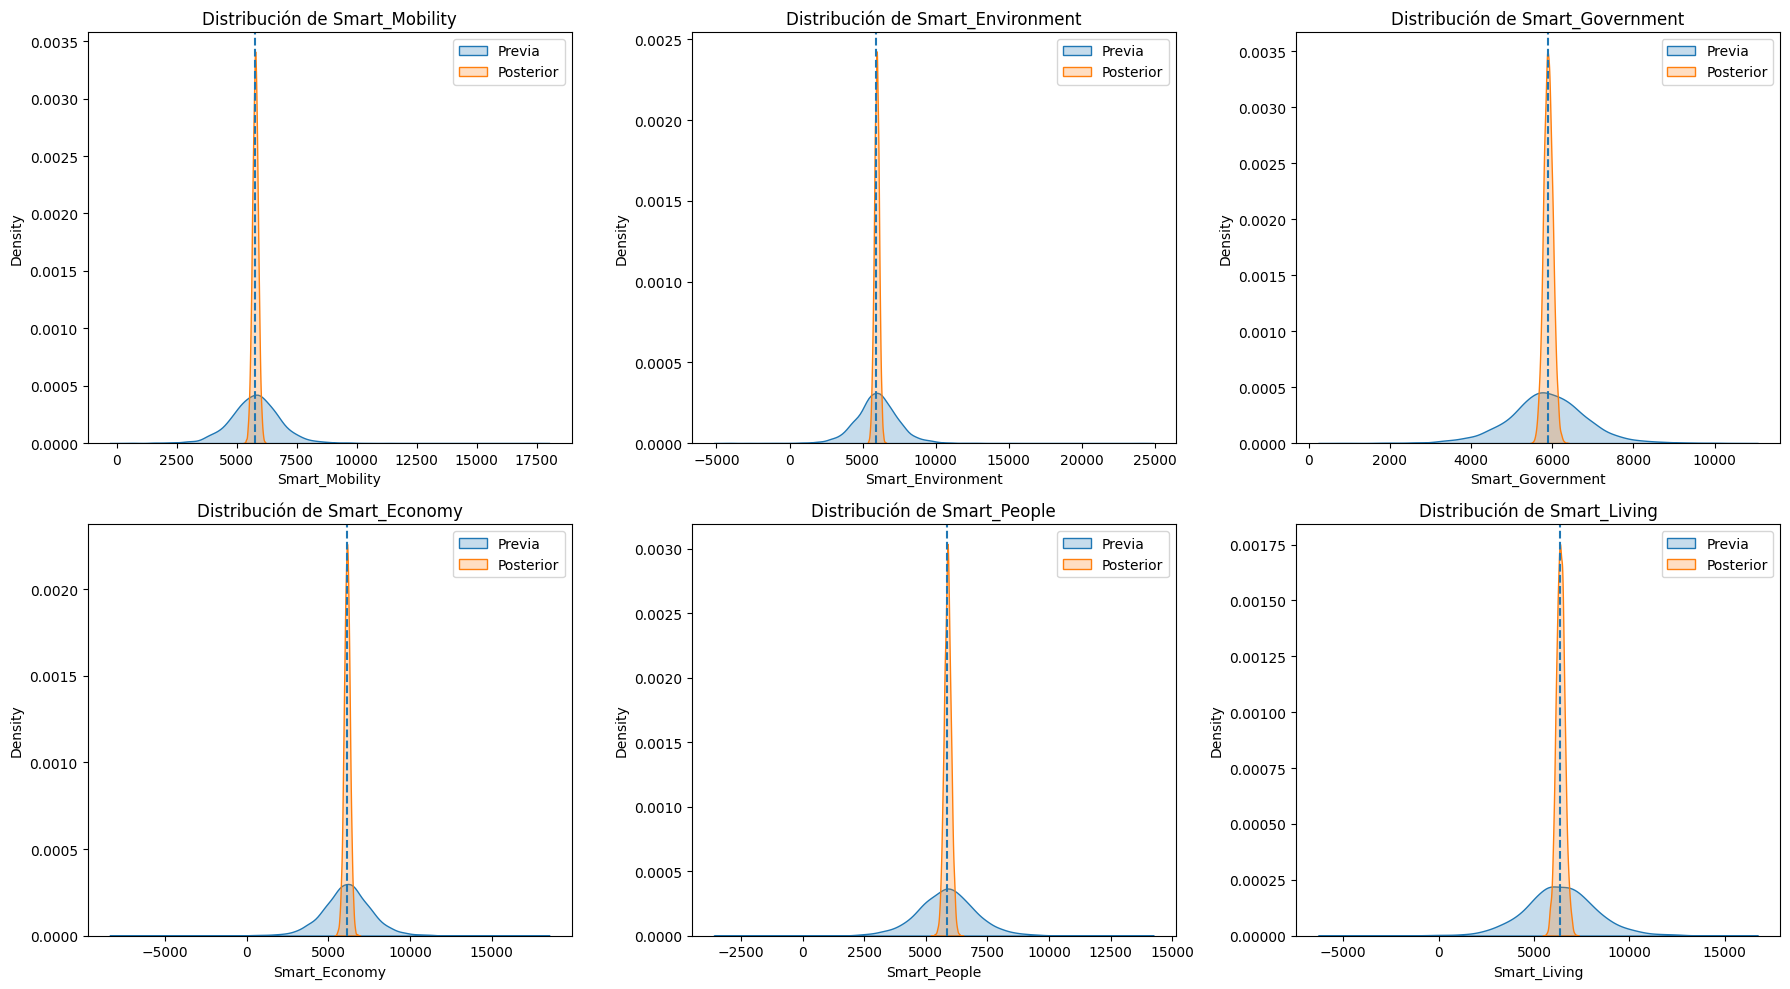

In [6]:
# ======================================================
# 7. Media previa y posterior de Sigma
# ======================================================
Sigma_prior_mean = Sigma_prior_draws.mean(axis=0)
Sigma_post_mean = Sigma_post_draws.mean(axis=0)

Sigma_prior_mean_df = pd.DataFrame(Sigma_prior_mean, index=vars_cluster, columns=vars_cluster)
Sigma_post_mean_df = pd.DataFrame(Sigma_post_mean, index=vars_cluster, columns=vars_cluster)

print("\nMedia previa de Sigma:")
print(Sigma_prior_mean_df.round(3))

print("\nMedia posterior de Sigma:")
print(Sigma_post_mean_df.round(3))

# ======================================================
# 8. Gráficas de theta: previa vs posterior
# ======================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(vars_cluster):
    sns.kdeplot(theta_prior_df[var], ax=axes[i], label="Previa", fill=True)
    sns.kdeplot(theta_post_df[var], ax=axes[i], label="Posterior", fill=True)
    axes[i].axvline(X[:, i].mean(), linestyle="--")
    axes[i].set_title(f"Distribución de {var}")
    axes[i].legend()

plt.tight_layout()
plt.show()


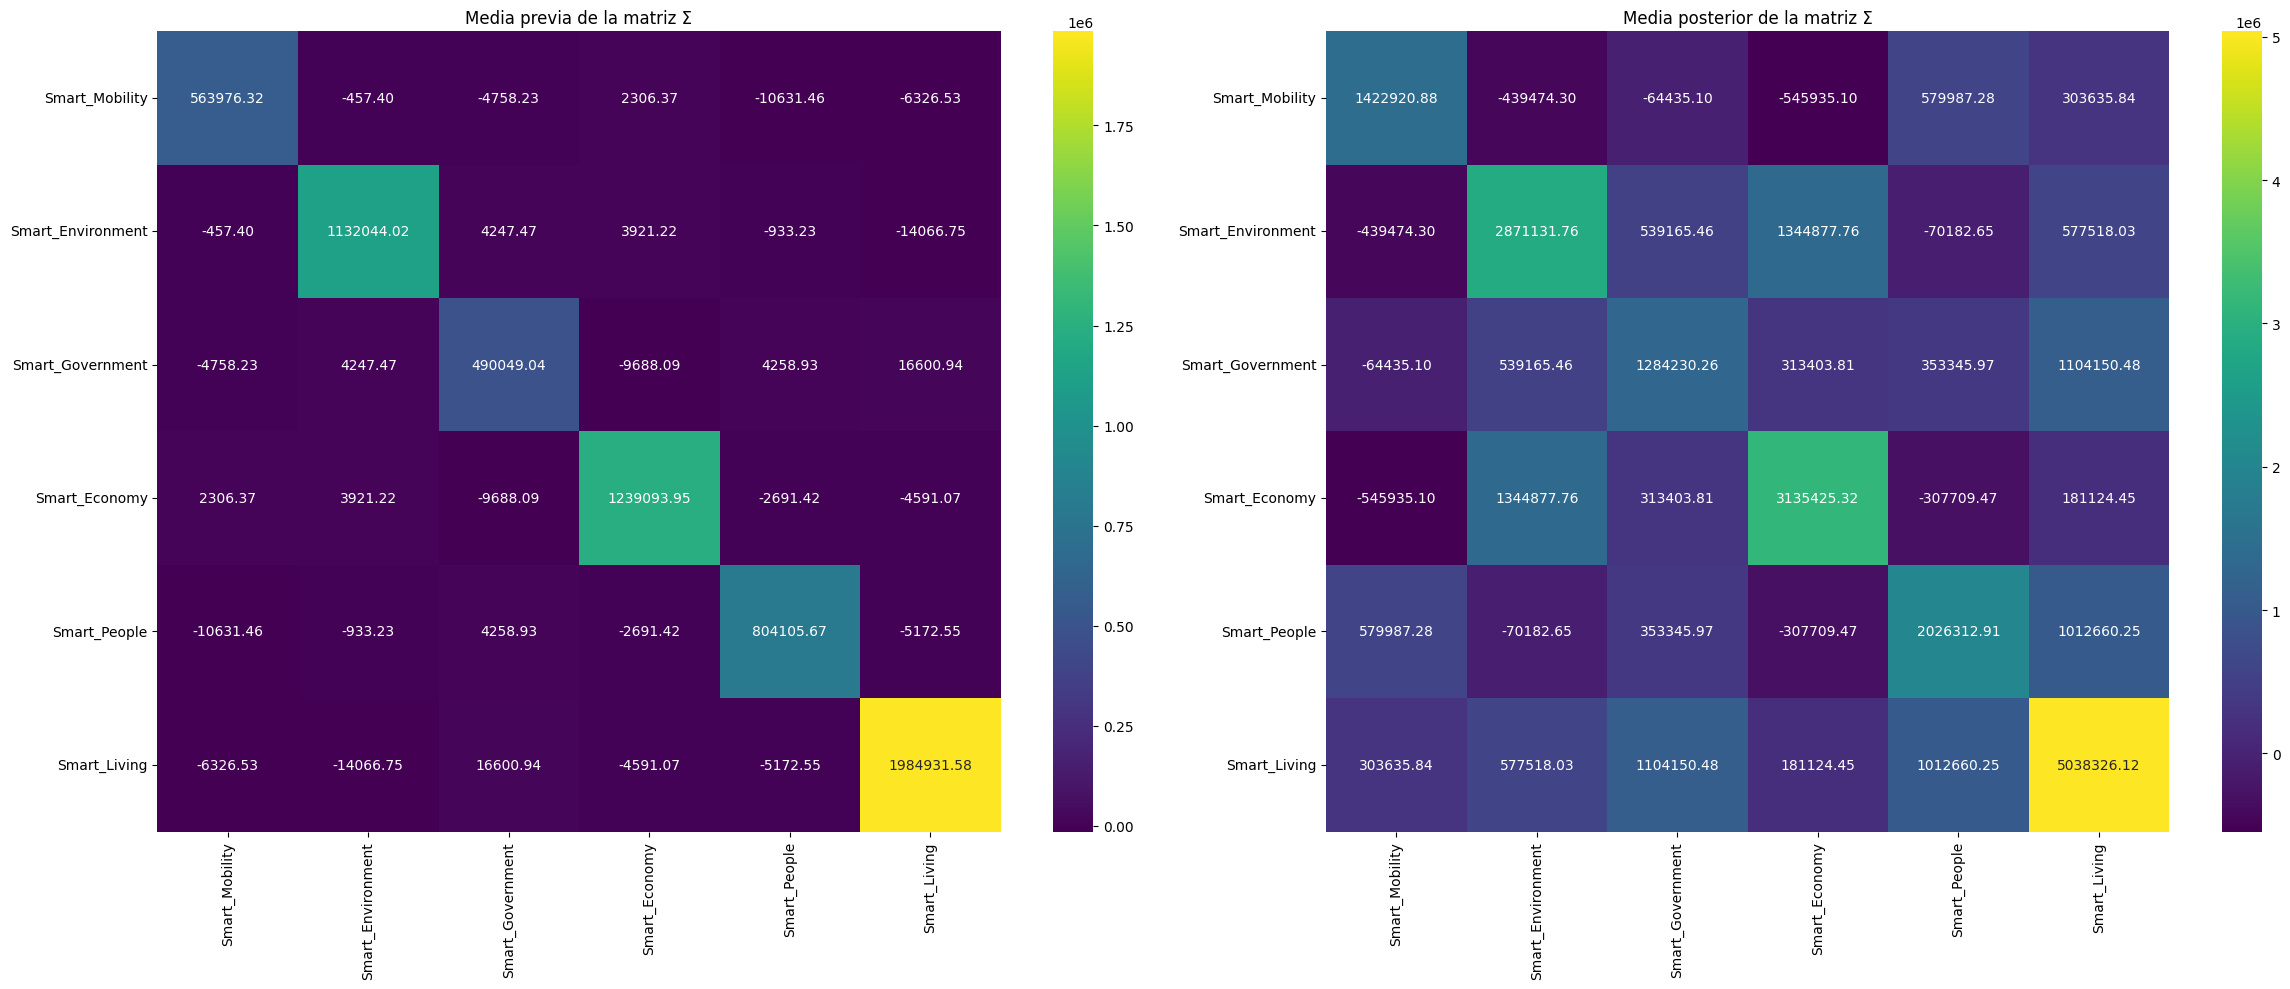

In [7]:

# ======================================================
# 9. Heatmaps de Sigma
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(
    Sigma_prior_mean,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=vars_cluster,
    yticklabels=vars_cluster,
    ax=axes[0]
)
axes[0].set_title("Media previa de la matriz Σ")

sns.heatmap(
    Sigma_post_mean,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=vars_cluster,
    yticklabels=vars_cluster,
    ax=axes[1]
)
axes[1].set_title("Media posterior de la matriz Σ")

plt.tight_layout()
plt.show()


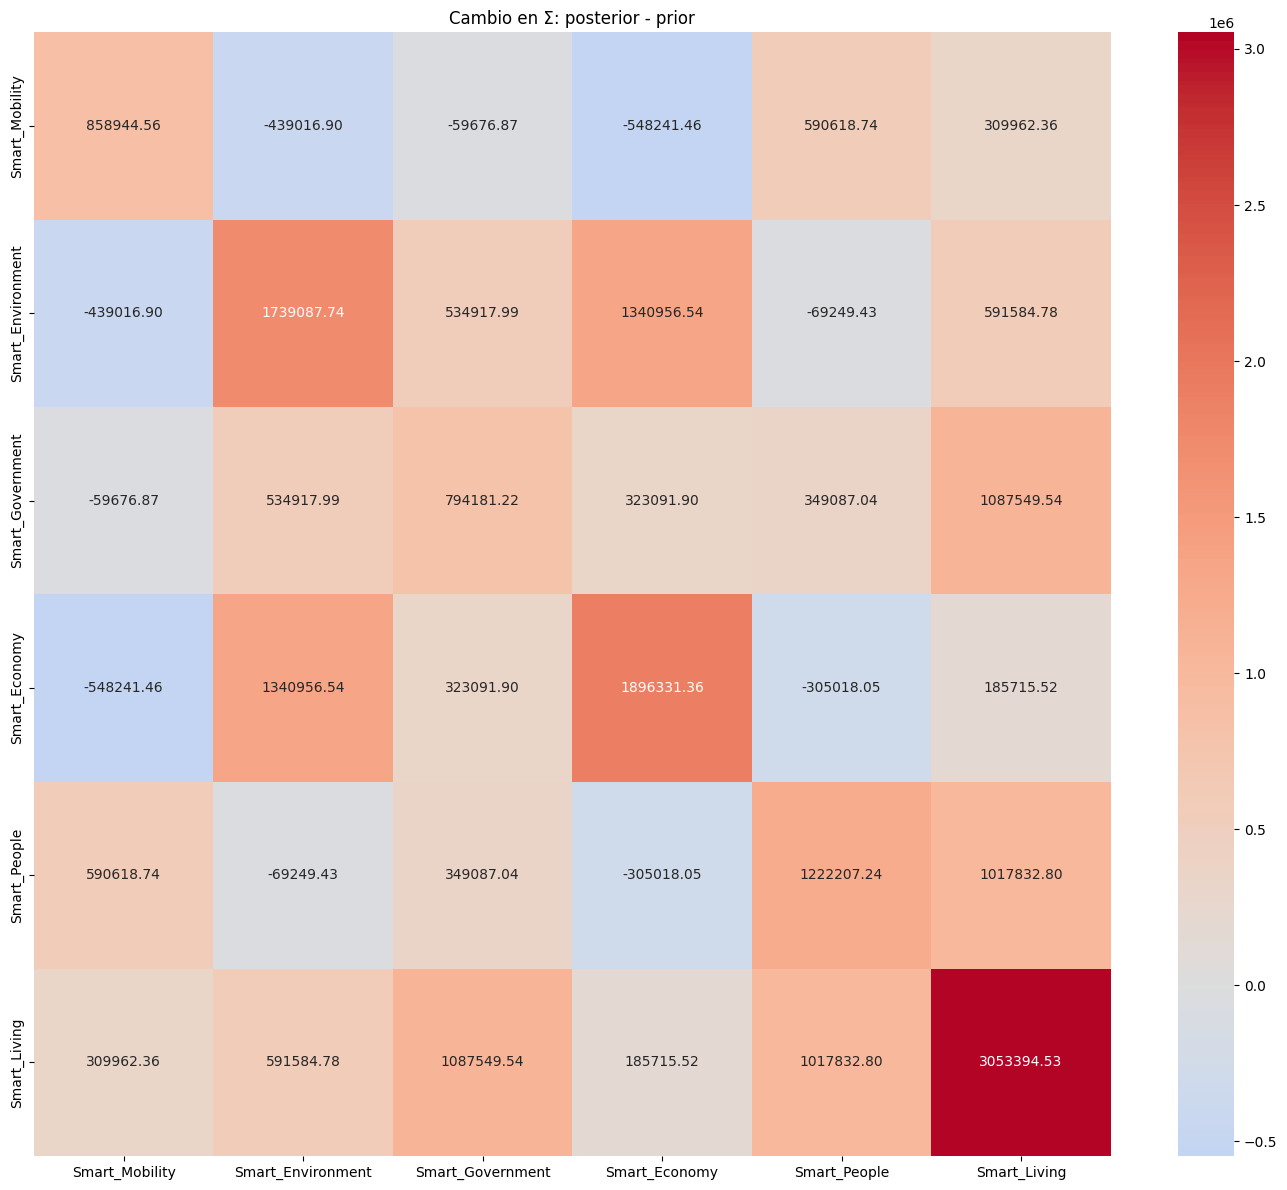

In [8]:

Sigma_diff = Sigma_post_mean - Sigma_prior_mean

plt.figure(figsize=(14, 12))
sns.heatmap(
    Sigma_diff,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=vars_cluster,
    yticklabels=vars_cluster
)
plt.title("Cambio en Σ: posterior - prior")
plt.tight_layout()
plt.show()


In [9]:

# ======================================================
# 10. Perfiles latentes por ciudad (shrinkage bayesiano)
# ======================================================
# Modelo:
# x_i | theta_i, Sigma ~ N(theta_i, Sigma)
# theta_i | mu, Sigma ~ N(mu, tau*Sigma)
# Entonces:
# E(theta_i | x_i, mu, Sigma) = (1/(1+tau))*mu + (tau/(1+tau))*x_i

mu_global = mu_n.copy()
tau = 2.0

theta_city = (1 / (1 + tau)) * mu_global + (tau / (1 + tau)) * X

theta_cols = [f"theta_{v}" for v in vars_cluster]
theta_city_df = pd.DataFrame(theta_city, columns=theta_cols)
theta_city_df = pd.concat([data[["City", "Country"]], theta_city_df], axis=1)

print("\nPerfiles latentes estimados por ciudad:")
print(theta_city_df.head())



Perfiles latentes estimados por ciudad:
         City      Country  theta_Smart_Mobility  theta_Smart_Environment  \
0        Oslo       Norway           6239.792524              6322.491870   
1      Bergen       Norway           6651.125857              6565.158537   
2   Amsterdam  Netherlands           6946.459190              5686.491870   
3  Copenhagen      Denmark           6913.125857              7261.158537   
4   Stockholm       Sweden           6001.125857              7109.158537   

   theta_Smart_Government  theta_Smart_Economy  theta_Smart_People  \
0             6975.259844          5087.259844         7703.341543   
1             6864.593177          5313.926510         7324.674876   
2             7649.926510          7440.593177         6690.008210   
3             7781.926510          5763.926510         5811.341543   
4             7533.926510          4930.593177         6453.341543   

   theta_Smart_Living  
0         8185.671608  
1         8185.671608  
2  

In [10]:

# ======================================================
# 11. Mezcla bayesiana de gaussianas sobre theta_i
# ======================================================
Theta = theta_city_df[theta_cols].values

scaler = StandardScaler()
Theta_scaled = scaler.fit_transform(Theta)

K_max = 8

bgm = BayesianGaussianMixture(
    n_components=K_max,
    covariance_type="full",
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.5,
    mean_precision_prior=1.0,
    covariance_prior=np.eye(Theta_scaled.shape[1]),
    init_params="kmeans",
    max_iter=5000,
    random_state=123
)

bgm.fit(Theta_scaled)

cluster_prob = bgm.predict_proba(Theta_scaled)
cluster_label = bgm.predict(Theta_scaled) + 1

theta_city_df["cluster_bayes"] = cluster_label
theta_city_df["cluster_prob_max"] = cluster_prob.max(axis=1)

weights_df = pd.DataFrame({
    "cluster": np.arange(1, K_max + 1),
    "peso_posterior_aprox": bgm.weights_
}).sort_values("peso_posterior_aprox", ascending=False)

print("\nPesos posteriores aproximados de los componentes:")
print(weights_df.round(4))

print("\nClusters activos (peso > 0.03):")
print(weights_df.loc[weights_df["peso_posterior_aprox"] > 0.03].round(4))



Pesos posteriores aproximados de los componentes:
   cluster  peso_posterior_aprox
1        2                0.2602
6        7                0.1807
5        6                0.1272
2        3                0.1203
7        8                0.1146
0        1                0.0680
3        4                0.0652
4        5                0.0638

Clusters activos (peso > 0.03):
   cluster  peso_posterior_aprox
1        2                0.2602
6        7                0.1807
5        6                0.1272
2        3                0.1203
7        8                0.1146
0        1                0.0680
3        4                0.0652
4        5                0.0638


In [11]:

# ======================================================
# 12. Tabla final de asignaciones
# ======================================================
assign_cols = ["City", "Country", "cluster_bayes", "cluster_prob_max"] + theta_cols
assignments_df = theta_city_df[assign_cols].sort_values(
    ["cluster_bayes", "cluster_prob_max"],
    ascending=[True, False]
)

print("\nAsignaciones de cluster:")
print(assignments_df.head(20))



Asignaciones de cluster:
           City               Country  cluster_bayes  cluster_prob_max  \
71        Seoul           South Korea              1          1.000000   
62      Daejeon           South Korea              1          1.000000   
74        Dubai  United Arab Emirates              1          1.000000   
80     Budapest               Hungary              1          1.000000   
69    Abu Dhabi  United Arab Emirates              1          1.000000   
61       Madrid                 Spain              1          0.998814   
28  Helsingborg                Sweden              2          0.999986   
31      Hamburg               Germany              2          0.999893   
79   Birmingham        United Kingdom              2          0.999742   
12     Västerås                Sweden              2          0.999564   
3    Copenhagen               Denmark              2          0.999330   
45      Cologne               Germany              2          0.999129   
25   Düsseld

In [12]:

# ======================================================
# 13. Perfil promedio de cada cluster
# ======================================================
cluster_summary = theta_city_df.groupby("cluster_bayes")[theta_cols].mean().round(3)
cluster_sizes = theta_city_df.groupby("cluster_bayes").size().rename("n_ciudades")
cluster_profile = cluster_sizes.to_frame().join(cluster_summary)

print("\nPerfil promedio por cluster:")
print(cluster_profile)



Perfil promedio por cluster:
               n_ciudades  theta_Smart_Mobility  theta_Smart_Environment  \
cluster_bayes                                                              
1                       6              6350.681                 4274.047   
2                      26              5937.844                 7125.569   
3                      12              6728.015                 5431.770   
4                       6              6318.348                 4584.492   
5                       6              5848.015                 3971.825   
6                      13              4899.434                 6207.825   
7                      20              4958.193                 6237.225   
8                      13              6029.177                 5643.210   

               theta_Smart_Government  theta_Smart_Economy  \
cluster_bayes                                                
1                            5379.927             3888.927   
2                      

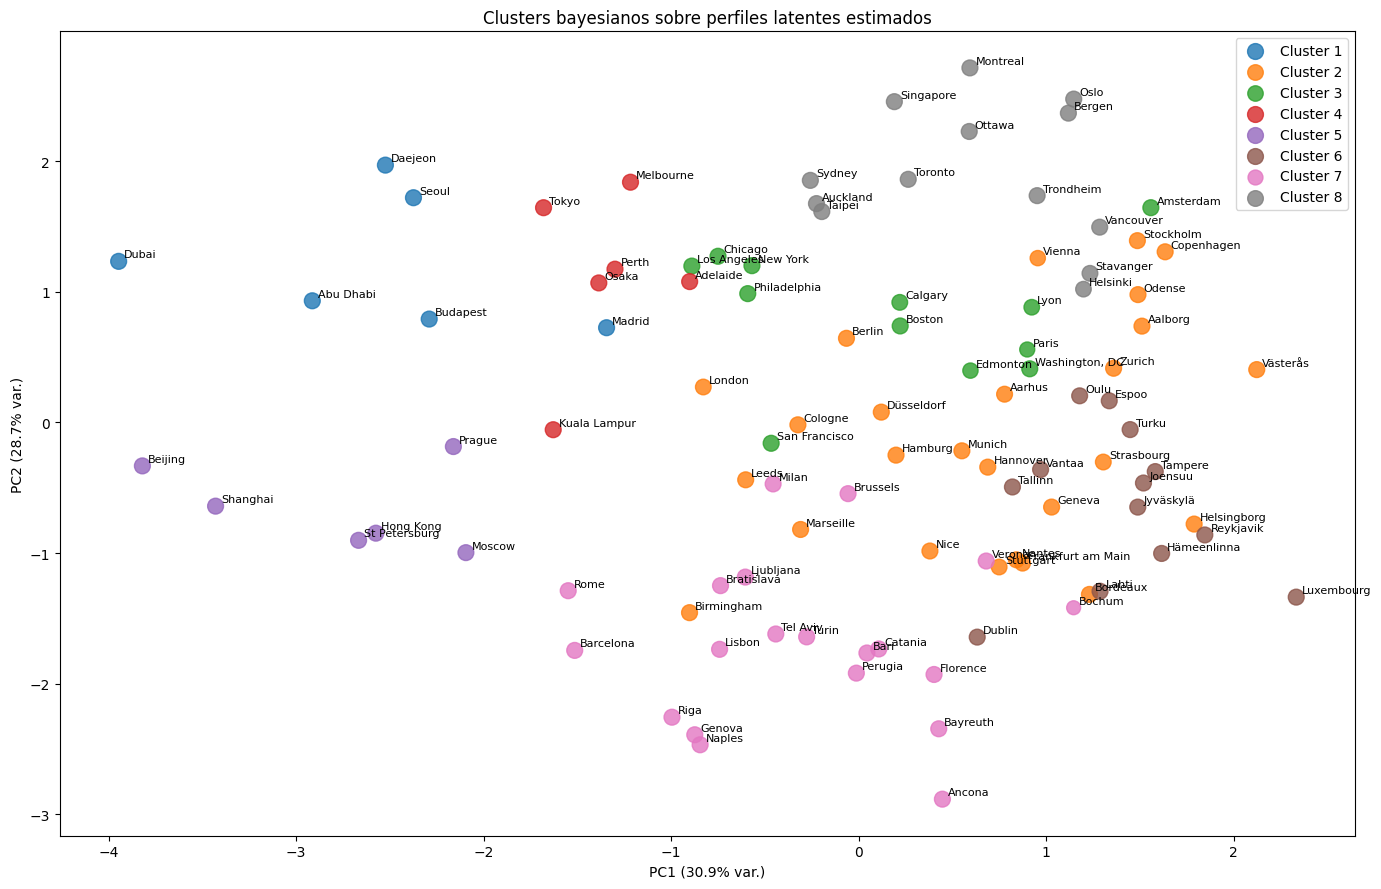

In [13]:

# ======================================================
# 14. PCA para visualización
# ======================================================
pca = PCA(n_components=2, random_state=123)
Theta_pca = pca.fit_transform(Theta_scaled)

plot_df = pd.DataFrame({
    "PC1": Theta_pca[:, 0],
    "PC2": Theta_pca[:, 1],
    "City": theta_city_df["City"].values,
    "Country": theta_city_df["Country"].values,
    "cluster_bayes": theta_city_df["cluster_bayes"].values,
    "cluster_prob_max": theta_city_df["cluster_prob_max"].values
})

plt.figure(figsize=(14, 9))

for cl in sorted(plot_df["cluster_bayes"].unique()):
    sub = plot_df[plot_df["cluster_bayes"] == cl]
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        s=40 + 90 * sub["cluster_prob_max"],
        alpha=0.8,
        label=f"Cluster {cl}"
    )

for _, row in plot_df.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["City"], fontsize=8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
plt.title("Clusters bayesianos sobre perfiles latentes estimados")
plt.legend()
plt.tight_layout()
plt.show()


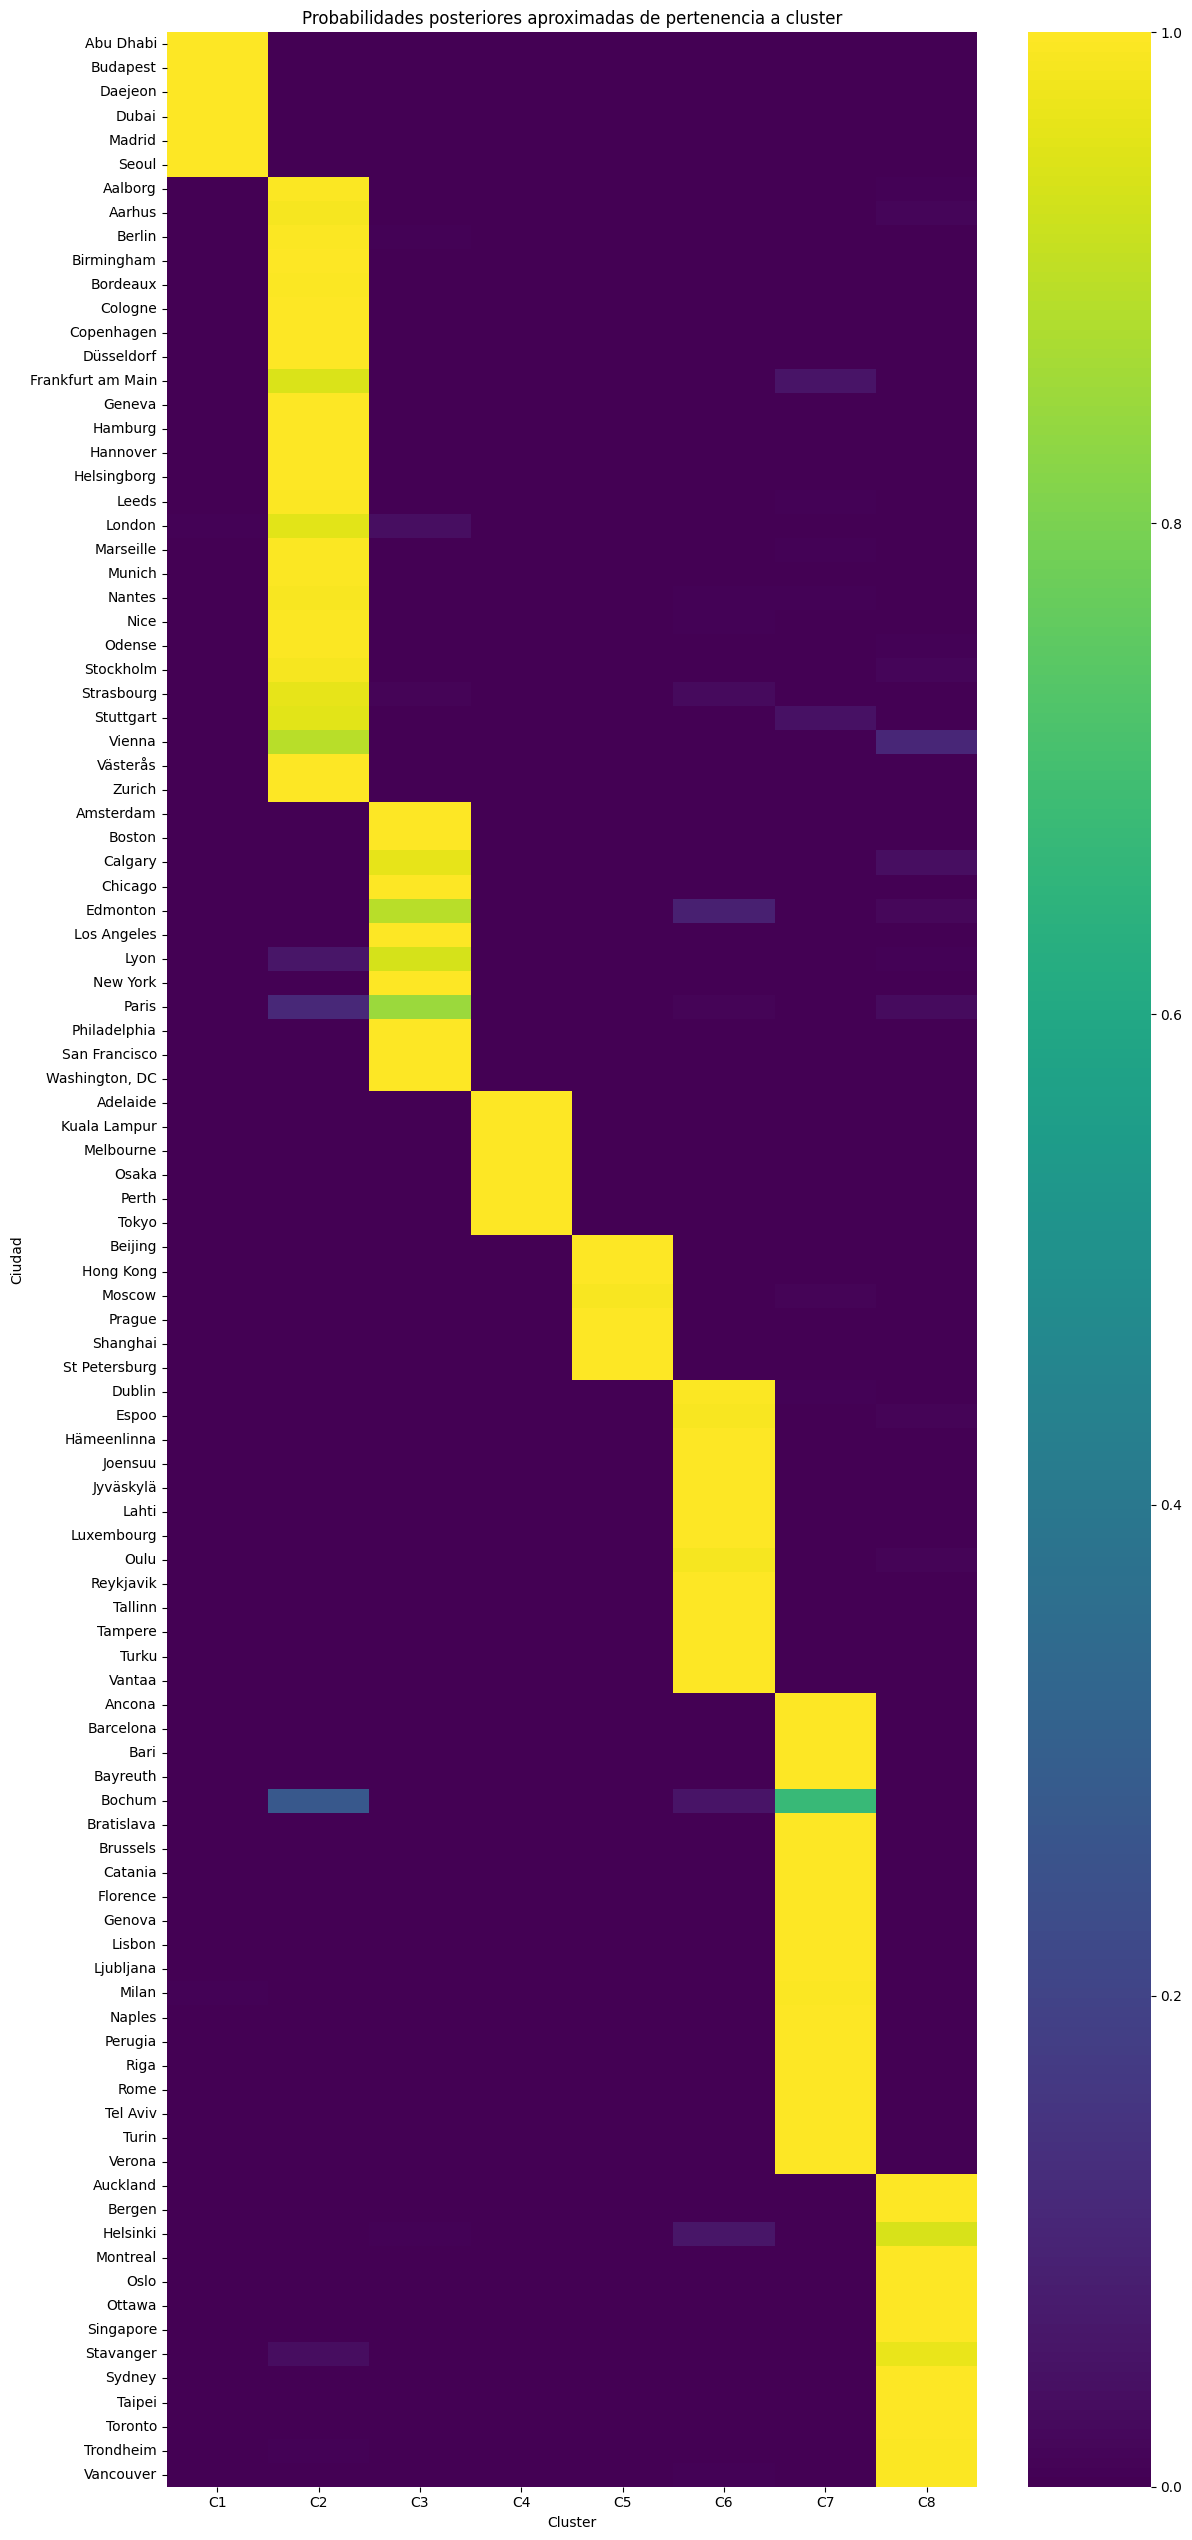

In [14]:

# ======================================================
# 15. Heatmap de probabilidades posteriores
# ======================================================
prob_cols = [f"C{k}" for k in range(1, K_max + 1)]
prob_df = pd.DataFrame(cluster_prob, columns=prob_cols)
prob_df.insert(0, "City", theta_city_df["City"].values)
prob_df.insert(1, "cluster_bayes", theta_city_df["cluster_bayes"].values)

prob_plot = prob_df.sort_values(["cluster_bayes", "City"]).set_index("City")[prob_cols]

plt.figure(figsize=(12, max(8, len(prob_plot) * 0.25)))
sns.heatmap(prob_plot, cmap="viridis")
plt.title("Probabilidades posteriores aproximadas de pertenencia a cluster")
plt.xlabel("Cluster")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()


In [15]:

# ======================================================
# 16. Ciudades representativas y ambiguas
# ======================================================
representative = theta_city_df.sort_values(
    ["cluster_bayes", "cluster_prob_max"],
    ascending=[True, False]
)

print("\nCiudades más representativas por cluster:")
print(
    representative.groupby("cluster_bayes")
    .head(3)[["City", "Country", "cluster_bayes", "cluster_prob_max"]]
)

print("\nCiudades más ambiguas (menor probabilidad máxima):")
print(
    theta_city_df.sort_values("cluster_prob_max")
    .head(10)[["City", "Country", "cluster_bayes", "cluster_prob_max"]]
)



Ciudades más representativas por cluster:
            City               Country  cluster_bayes  cluster_prob_max
71         Seoul           South Korea              1          1.000000
62       Daejeon           South Korea              1          1.000000
74         Dubai  United Arab Emirates              1          1.000000
28   Helsingborg                Sweden              2          0.999986
31       Hamburg               Germany              2          0.999893
79    Birmingham        United Kingdom              2          0.999742
23       Chicago         United States              3          1.000000
9         Boston         United States              3          1.000000
17   Los Angeles         United States              3          1.000000
53         Tokyo                 Japan              4          1.000000
58         Osaka                 Japan              4          1.000000
93  Kuala Lampur              Malaysia              4          1.000000
98       Beijing     

In [16]:

# ======================================================
# 17. Guardar resultados
# ======================================================
assignments_df.to_csv("clusters_bayes_smart_cities.csv", index=False)
cluster_profile.to_csv("cluster_profile_smart_cities.csv")
prob_df.to_csv("cluster_probabilities_smart_cities.csv", index=False)

print("\nArchivos guardados:")
print("- clusters_bayes_smart_cities.csv")
print("- cluster_profile_smart_cities.csv")
print("- cluster_probabilities_smart_cities.csv")


Archivos guardados:
- clusters_bayes_smart_cities.csv
- cluster_profile_smart_cities.csv
- cluster_probabilities_smart_cities.csv
